# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 01 - Data Exploration and Preprocessing

**Syllabus coverage - UNIT I**

| Topic from the unitization plan | Where it appears below |
|---|---|
| Introduction to Machine Learning | Section 1 |
| Different types of learning | Section 1 |
| Training, Testing, validation of models | Section 6 |
| Evaluation of the model: Train data, Test data | Section 6 |
| Overfitting and Underfitting | Section 7 |

## 1. Problem definition and type of learning

Credit card fraud detection is a **supervised learning** problem: we are given
historical transactions in which each record already carries a label
(`Class` = 1 for fraud, 0 for legitimate), and the task is to learn a mapping
from the input attributes to that label.

Within supervised learning this is a **binary classification** problem, as
opposed to regression, because the output is a discrete category rather than a
continuous value.

The **hypothesis space** differs from algorithm to algorithm - axis-parallel
splits for a decision tree, a separating hyperplane for an SVM, a set of stored
instances for k-NN - and each algorithm's **inductive bias** is the assumption
it makes in order to generalise beyond the training data. These are examined in
the individual model notebooks that follow.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 2. The dataset

The dataset is the well known credit card transactions dataset published by the
Machine Learning Group of the Universite Libre de Bruxelles (ULB). It records
transactions made by European cardholders over two days in September 2013.

An important property for this project: the attributes `V1` to `V28` are **not**
the original transaction attributes. They are **principal components** obtained
by applying PCA to the original features, published in that form to protect
cardholder confidentiality. Only `Time`, `Amount` and `Class` are untransformed.
PCA is a Unit II topic and is studied directly in Notebook 02.

In [2]:
print("shape:", df.shape)
df.head()

shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-nu

In [4]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.078,47481.048,0.000,54204.750,84692.500,139298.000,172792.000
V1,283726.0,0.006,1.948,-56.408,-0.916,0.020,1.316,2.455
V2,283726.0,-0.004,1.647,-72.716,-0.600,0.064,0.800,22.058
V3,283726.0,0.002,1.509,-48.326,-0.890,0.180,1.027,9.383
V4,283726.0,-0.003,1.414,-5.683,-0.850,-0.022,0.740,16.875
V5,283726.0,0.002,1.377,-113.743,-0.690,-0.053,0.612,34.802
V6,283726.0,-0.001,1.332,-26.161,-0.769,-0.275,0.397,73.302
V7,283726.0,0.002,1.228,-43.557,-0.553,0.041,0.570,120.589
V8,283726.0,-0.001,1.179,-73.217,-0.209,0.022,0.326,20.007
V9,283726.0,-0.002,1.095,-13.434,-0.644,-0.053,0.596,15.595


## 3. Data quality checks

In [5]:
print("missing values per column:", df.isnull().sum().sum())
print("duplicate rows remaining :", df.duplicated().sum())

missing values per column: 0


duplicate rows remaining : 0


Exact duplicate rows were removed while loading the data. This matters: if the
same transaction appeared twice and the split placed one copy in the training
set and the other in the test set, the model would be tested on a record it had
already memorised, and the reported accuracy would be optimistic.

## 4. Class distribution - the central difficulty

This is the single most important property of the dataset and it shapes every
decision made later in the project.

In [6]:
counts = df["Class"].value_counts()
print(counts)
print()
print(f"legitimate : {counts[0]:,}  ({counts[0]/len(df)*100:.4f}%)")
print(f"fraudulent : {counts[1]:,}  ({counts[1]/len(df)*100:.4f}%)")
print(f"imbalance ratio : 1 fraud for every {counts[0]//counts[1]:,} legitimate transactions")

Class
0    283253
1       473
Name: count, dtype: int64

legitimate : 283,253  (99.8333%)
fraudulent : 473  (0.1667%)
imbalance ratio : 1 fraud for every 598 legitimate transactions


saved figure -> Results/figures/01_class_distribution.png


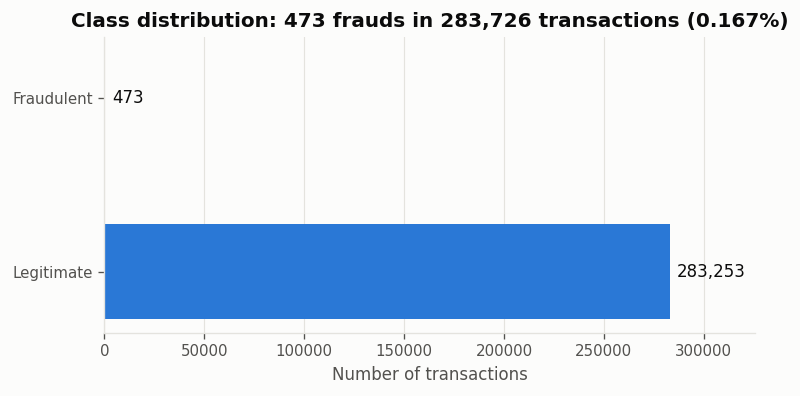

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(["Legitimate", "Fraudulent"], [counts[0], counts[1]],
        color=[utils.BLUE, utils.RED], height=0.55)
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(v + counts[0]*0.012, i, f"{v:,}", va="center", fontsize=10, color=utils.INK)
ax.set_xlim(0, counts[0]*1.15)
ax.set_xlabel("Number of transactions")
ax.set_title(f"Class distribution: {counts[1]} frauds in {len(df):,} transactions "
             f"({df.Class.mean()*100:.3f}%)")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "01_class_distribution.png")
plt.show()

### Why accuracy cannot be used as the evaluation metric

Consider the simplest possible classifier: one that ignores its input entirely
and always answers "legitimate".

In [8]:
trivial_accuracy = (df.Class == 0).mean()
print(f"'always legitimate' classifier")
print(f"  accuracy : {trivial_accuracy*100:.4f}%")
print(f"  frauds detected : 0 out of {int(df.Class.sum())}")

'always legitimate' classifier
  accuracy : 99.8333%
  frauds detected : 0 out of 473


A classifier that detects **no fraud whatsoever** scores above 99.8% accuracy.
Accuracy is therefore meaningless on this problem, and every model in this
project is judged primarily on **recall** (what fraction of frauds are caught),
**precision**, **F1-score** and **PR-AUC** instead. Accuracy is still reported
in the comparison table, but only so that this point remains visible.

## 5. Exploring the untransformed attributes

`Amount` and `Time` are the only two attributes that retain their original
meaning, so they are the only ones that can be interpreted directly.

In [9]:
legit = df.loc[df.Class == 0, "Amount"]
fraud = df.loc[df.Class == 1, "Amount"]
print("Legitimate transaction amounts (EUR):"); print(legit.describe().round(2))
print("\nFraudulent transaction amounts (EUR):"); print(fraud.describe().round(2))
print(f"\nmean legitimate : {legit.mean():.2f}")
print(f"mean fraudulent : {fraud.mean():.2f}")

Legitimate transaction amounts (EUR):
count    283253.00
mean         88.41
std         250.38
min           0.00
25%           5.67
50%          22.00
75%          77.46
max       25691.16
Name: Amount, dtype: float64

Fraudulent transaction amounts (EUR):
count     473.00
mean      123.87
std       260.21
min         0.00
25%         1.00
50%         9.82
75%       105.89
max      2125.87
Name: Amount, dtype: float64

mean legitimate : 88.41
mean fraudulent : 123.87


saved figure -> Results/figures/01_amount_distribution.png


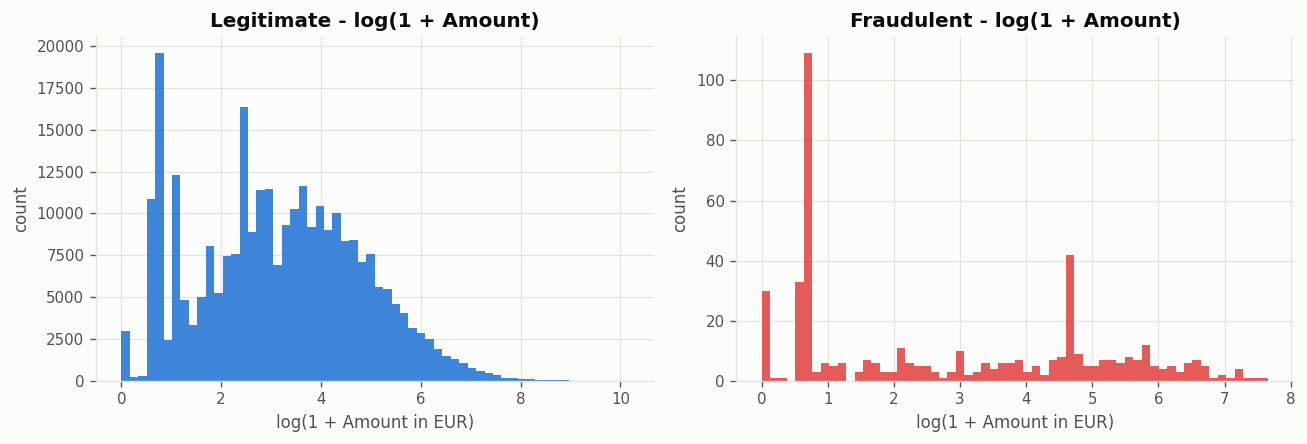

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, s, name, c in zip(axes, [legit, fraud], ["Legitimate", "Fraudulent"],
                          [utils.BLUE, utils.RED]):
    ax.hist(np.log1p(s), bins=60, color=c, alpha=0.9)
    ax.set_title(f"{name} - log(1 + Amount)")
    ax.set_xlabel("log(1 + Amount in EUR)"); ax.set_ylabel("count")
    utils.despine(ax)
plt.tight_layout()
utils.save_fig(fig, "01_amount_distribution.png")
plt.show()

Fraudulent transactions are on average **larger** than legitimate ones. The
amount therefore carries some signal, although as the histograms show the two
distributions overlap heavily and no threshold on `Amount` alone could separate
them.

saved figure -> Results/figures/01_fraud_by_hour.png


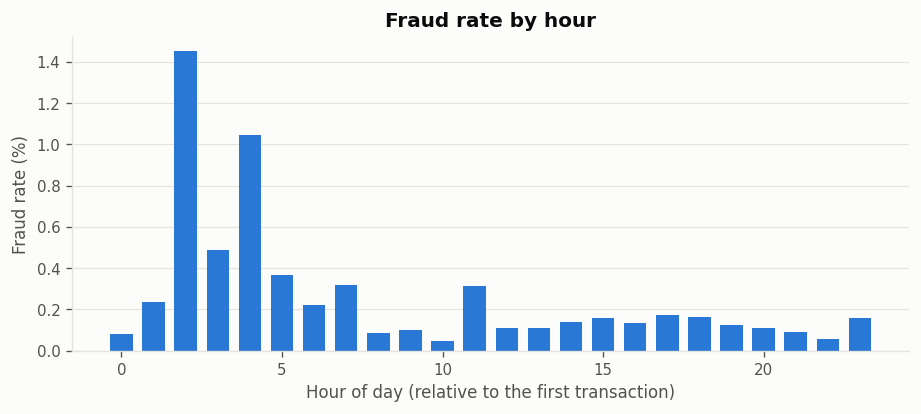

hour
0.0     0.078
1.0     0.238
2.0     1.451
3.0     0.488
4.0     1.044
5.0     0.368
6.0     0.220
7.0     0.318
8.0     0.088
9.0     0.101
10.0    0.048
11.0    0.316
12.0    0.111
13.0    0.111
14.0    0.139
15.0    0.159
16.0    0.134
17.0    0.174
18.0    0.165
19.0    0.122
20.0    0.108
21.0    0.091
22.0    0.059
23.0    0.156
Name: Class, dtype: float64

In [11]:
d = df.assign(hour=(df["Time"] // 3600) % 24)
rate = d.groupby("hour")["Class"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(rate.index, rate.values, color=utils.BLUE, width=0.7)
ax.set_xlabel("Hour of day (relative to the first transaction)")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by hour")
ax.grid(axis="x", visible=False); utils.despine(ax)
utils.save_fig(fig, "01_fraud_by_hour.png")
plt.show()
rate.round(3)

Fraud is not uniformly distributed across the day. The rate rises sharply in the
early morning hours, when genuine transaction volume is at its lowest.

## 6. Training, testing and validation of models (Unit I)

The dataset is divided into a **training set**, used to fit the model, and a
**test set**, held back and used only to measure performance on data the model
has never seen. Measuring on the training data alone would tell us how well the
model memorised, not how well it generalises.

Two choices matter here:

- **Stratification.** Because only 0.17% of records are fraudulent, a random
  split could easily produce a test set with a very different fraud rate from
  the training set. Stratified splitting forces both parts to preserve the
  original class proportion.
- **A fixed random seed (77).** Without it, the split would change on every run
  and results could not be reproduced or compared across notebooks.

For model selection within the training data, **k-fold cross validation** is
used (5 folds, stratified). The training set is divided into 5 parts; the model
is trained on 4 and validated on the remaining 1, rotating through all 5. This
gives a more stable estimate than a single validation split, which is valuable
when the positive class is this small.

In [12]:
print(f"train : {X_train.shape[0]:,} rows, {int(y_train.sum())} frauds "
      f"({y_train.mean()*100:.4f}%)")
print(f"test  : {X_test.shape[0]:,} rows, {int(y_test.sum())} frauds "
      f"({y_test.mean()*100:.4f}%)")
print("\nThe fraud proportion is preserved in both parts, as intended.")
print("\nCross validation object used for model selection:")
print(utils.cv())

train : 198,608 rows, 331 frauds (0.1667%)
test  : 85,118 rows, 142 frauds (0.1668%)

The fraud proportion is preserved in both parts, as intended.

Cross validation object used for model selection:
StratifiedKFold(n_splits=5, random_state=77, shuffle=True)


## 7. Overfitting and underfitting (Unit I)

**Underfitting** happens when the model is too simple to capture the structure
in the data: it performs poorly on both training and test data.
**Overfitting** happens when the model is complex enough to memorise the
training data, including its noise: training performance is excellent while test
performance is poor.

The demonstration below uses a decision tree of increasing depth. Depth is a
direct measure of model complexity, so the gap between the training and test
curves shows overfitting appearing as the tree is allowed to grow.

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, None]
train_f1, test_f1, labels = [], [], []
for d in depths:
    t = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED)
    t.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, t.predict(X_train)))
    test_f1.append(f1_score(y_test, t.predict(X_test)))
    labels.append(d if d is not None else "full")
    print(f"depth {str(labels[-1]):>4} : train F1 {train_f1[-1]:.4f} | test F1 {test_f1[-1]:.4f}")

depth    1 : train F1 0.7136 | test F1 0.6992


depth    2 : train F1 0.7500 | test F1 0.7323


depth    3 : train F1 0.8132 | test F1 0.8293


depth    4 : train F1 0.8247 | test F1 0.7923


depth    5 : train F1 0.8675 | test F1 0.8145


...

depth   12 : train F1 0.9768 | test F1 0.7842


depth   15 : train F1 0.9985 | test F1 0.7774


depth   20 : train F1 1.0000 | test F1 0.7774


depth   25 : train F1 1.0000 | test F1 0.7774


depth full : train F1 1.0000 | test F1 0.7774


saved figure -> Results/figures/01_overfitting_underfitting.png


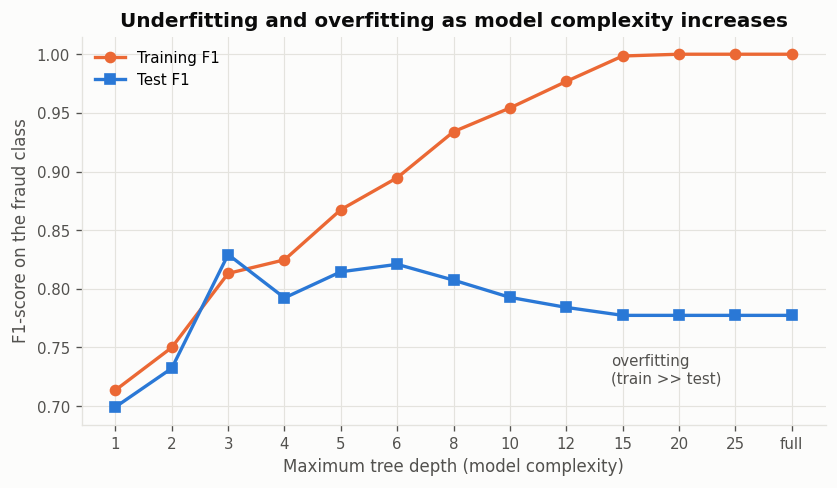

In [14]:
xs = range(len(depths))
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(xs, train_f1, marker="o", color=utils.ORANGE, label="Training F1")
ax.plot(xs, test_f1,  marker="s", color=utils.BLUE,   label="Test F1")
ax.set_xticks(list(xs)); ax.set_xticklabels([str(l) for l in labels])
ax.set_xlabel("Maximum tree depth (model complexity)")
ax.set_ylabel("F1-score on the fraud class")
ax.set_title("Underfitting and overfitting as model complexity increases")
ax.annotate("underfitting\n(too simple)", xy=(0.4, 0.35), fontsize=9, color=utils.INK2)
ax.annotate("overfitting\n(train >> test)", xy=(len(depths)-4.2, 0.72), fontsize=9,
            color=utils.INK2)
ax.legend(); utils.despine(ax)
utils.save_fig(fig, "01_overfitting_underfitting.png")
plt.show()

At small depths both curves are low - the tree is too simple and **underfits**.
As depth grows the training F1 climbs towards 1.0 while the test F1 flattens and
then declines: the tree is **overfitting**, memorising the training set rather
than learning a rule that generalises. The best test performance occurs at
moderate depth, which is why the decision tree in Notebook 03 is pruned with
`max_depth` rather than grown without limit.

## 8. Correlation with the target

Which attributes separate the two classes most strongly?

saved figure -> Results/figures/01_correlation.png


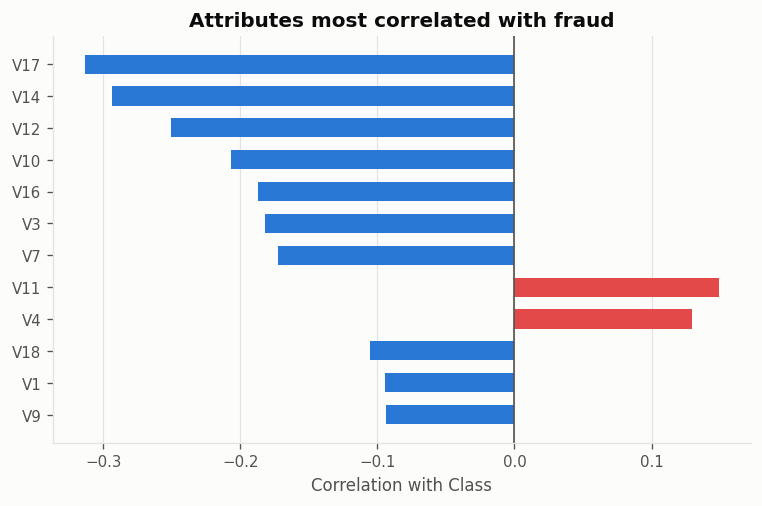

V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
V16   -0.1872
V3    -0.1823
V7    -0.1723
V11    0.1491
V4     0.1293
V18   -0.1053
V1    -0.0945
V9    -0.0940
Name: Class, dtype: float64

In [15]:
corr = df.corr(numeric_only=True)["Class"].drop("Class").sort_values(key=abs, ascending=False)
top = corr.head(12)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
colors = [utils.RED if v > 0 else utils.BLUE for v in top.values[::-1]]
ax.barh(top.index[::-1], top.values[::-1], color=colors, height=0.6)
ax.axvline(0, color=utils.INK2, linewidth=1)
ax.set_xlabel("Correlation with Class"); ax.set_title("Attributes most correlated with fraud")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "01_correlation.png")
plt.show()
top.round(4)

The strongest signals come from `V17`, `V14`, `V12`, `V10` and `V4`. Every one of
them is a principal component, so while they are statistically informative they
carry no human-readable meaning - a limitation revisited in Notebook 02.

## 9. Summary

- 283,726 transactions after removing 1,081 duplicates; 473 are fraudulent
  (**0.1667%**).
- No missing values.
- A trivial "always legitimate" classifier scores **99.83% accuracy** and
  catches no fraud, so accuracy is rejected as the evaluation metric in favour of
  recall, precision, F1 and PR-AUC.
- Fraudulent transactions are larger on average and concentrated in the early
  morning hours.
- The data is split 70/30 with stratification and seed 77; 5-fold stratified
  cross validation is used for model selection.
- A depth sweep on a decision tree demonstrates underfitting at low complexity
  and overfitting at high complexity.

In [16]:
import json
summary = {
    "n_transactions": int(len(df)),
    "n_fraud": int(df.Class.sum()),
    "fraud_rate": float(df.Class.mean()),
    "n_duplicates_removed": 1081,
    "trivial_accuracy": float((df.Class == 0).mean()),
    "train_rows": int(len(y_train)), "train_frauds": int(y_train.sum()),
    "test_rows": int(len(y_test)),  "test_frauds": int(y_test.sum()),
    "mean_fraud_amount": float(df.loc[df.Class==1,"Amount"].mean()),
    "mean_legit_amount": float(df.loc[df.Class==0,"Amount"].mean()),
    "seed": SEED,
}
with open(utils.TAB_DIR / "dataset_summary.json", "w") as fh:
    json.dump(summary, fh, indent=1)
print(json.dumps(summary, indent=1))

{
 "n_transactions": 283726,
 "n_fraud": 473,
 "fraud_rate": 0.001667101358352777,
 "n_duplicates_removed": 1081,
 "trivial_accuracy": 0.9983328986416472,
 "train_rows": 198608,
 "train_frauds": 331,
 "test_rows": 85118,
 "test_frauds": 142,
 "mean_fraud_amount": 123.87186046511628,
 "mean_legit_amount": 88.41357475472458,
 "seed": 77
}
